1.Importing the dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

2.Data cleaning

In [ ]:
# Load the dataset
df = pd.read_csv('loan_dataset_20000.csv')

# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Standardizing column names (optional but good practice)
df.columns = [col.strip() for col in df.columns]

Missing values in each column:
 age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64
Number of duplicate rows: 0


3.Data visualization

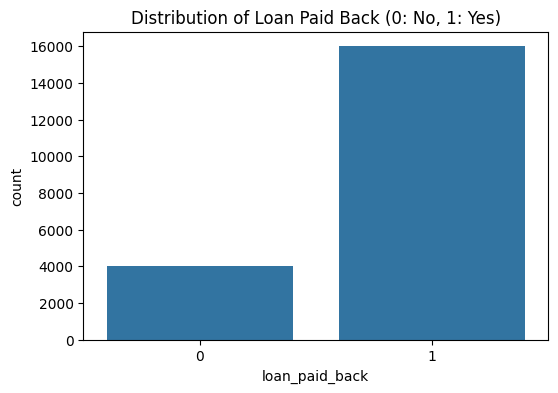

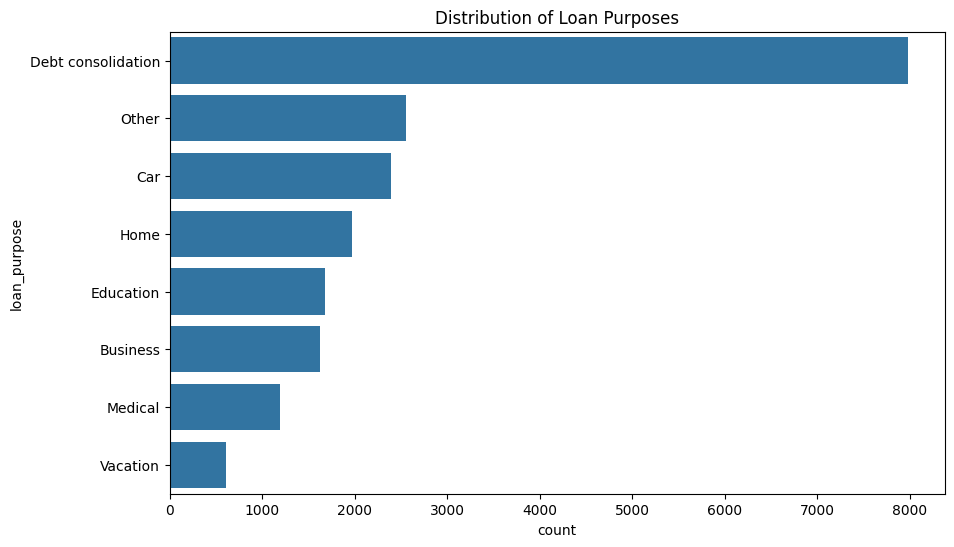

In [ ]:
# Distribution of the Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_paid_back', data=df)
plt.title('Distribution of Loan Paid Back (0: No, 1: Yes)')
plt.savefig('loan_paid_back_dist.png')

# Loan Purpose Distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='loan_purpose', data=df, order=df['loan_purpose'].value_counts().index)
plt.title('Distribution of Loan Purposes')
plt.savefig('loan_purpose_dist.png')

4.Exploratory Data Analysis (EDA)

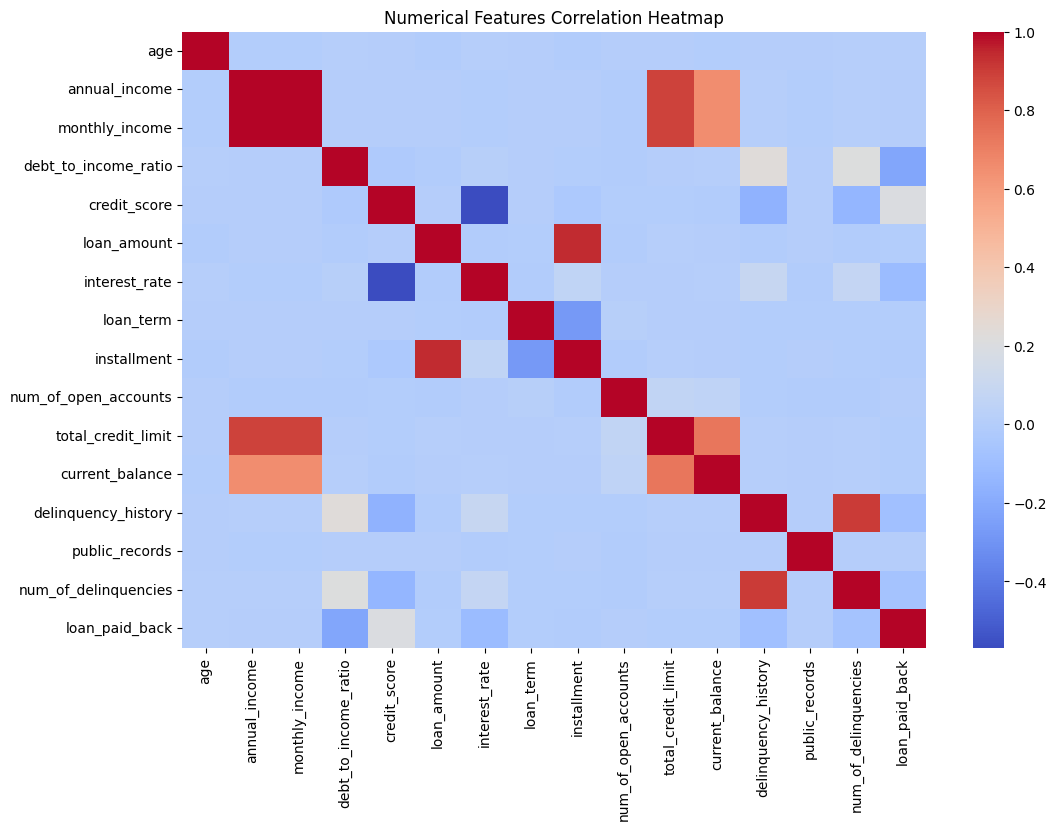

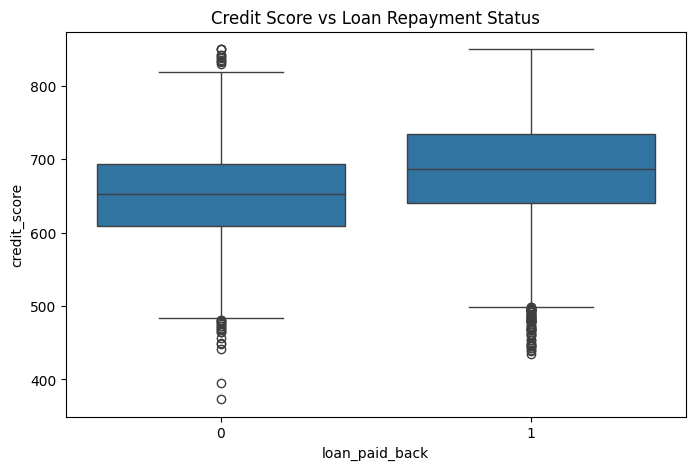

In [ ]:
# Correlation between numerical variables
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Numerical Features Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# Checking the relationship between Credit Score and Loan Repayment
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_paid_back', y='credit_score', data=df)
plt.title('Credit Score vs Loan Repayment Status')
plt.savefig('credit_score_boxplot.png')

5.Data Modeling (Preprocessing)

In [ ]:
# Encoding categorical columns using LabelEncoder
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    # Store encoder if needed for app.py
    joblib.dump(le, f'encoder_{col}.sav')

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


6.Splitting the data into features and targets

In [ ]:
X = df.drop('loan_paid_back', axis=1) # Features
y = df['loan_paid_back']              # Target

7.Splitting the data into test and training data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8.Model training

In [ ]:
# Using Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

9.Model evaluation

In [ ]:
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


--- Model Evaluation ---
Accuracy Score: 89.62%

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.53      0.68       818
           1       0.89      0.99      0.94      3182

    accuracy                           0.90      4000
   macro avg       0.91      0.76      0.81      4000
weighted avg       0.90      0.90      0.88      4000



10.Communication and Visualization

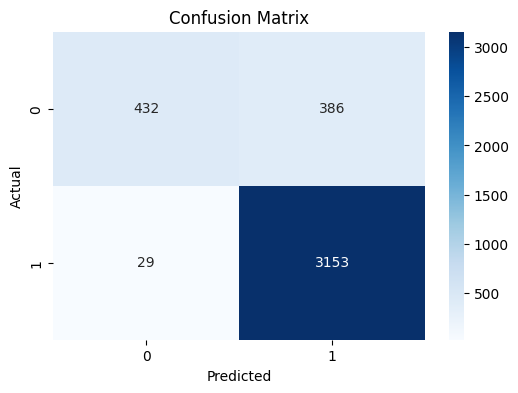

In [ ]:
# Plotting the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')

11.Model saving

In [ ]:
# Saving the model as a .sav file
model_filename = 'loan_model.sav'
joblib.dump(model, model_filename)
print(f"Model saved successfully as {model_filename}")

Model saved successfully as loan_model.sav
